# Keyword Extraction — 01 Exploring the Data

**Keyword / keyphrase extraction**: automatically pull the most important words from an article. We use 200 CNN/DailyMail news articles (with their reference summaries, which we treat as a proxy for the 'key content' to evaluate against). This notebook explores the text.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline
import utils

df=utils.load_articles()
df['n_words']=df['article'].str.split().apply(len)
print('articles:',len(df),'| median words:',int(df['n_words'].median()))
df.head(2)

articles: 200 | median words: 427


,article,summary,n_words
0,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...,567
1,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b...",411


## 1. Article length & vocabulary

content tokens (100 articles): 24930 | unique: 7565


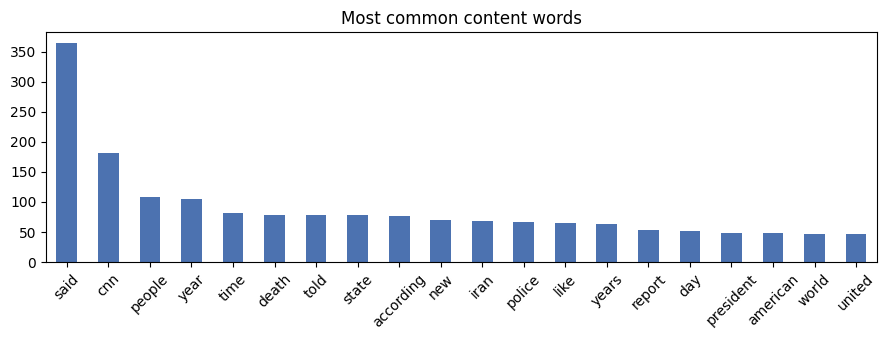

In [2]:
alltok=[w for t in df['article'].head(100) for w in utils.tokens(t)]
print('content tokens (100 articles):',len(alltok),'| unique:',len(set(alltok)))
top=pd.Series(dict(Counter(alltok).most_common(20)))
fig,ax=plt.subplots(figsize=(9,3.5)); top.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Most common content words'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 2. A sample article

Note: the most *frequent* words above are generic; good keywords are words that are frequent **in this article but rare elsewhere** — exactly what TF-IDF captures.

In [3]:
print(df.iloc[0]['article'][:400],'...')
print('\nReference summary:',df.iloc[0]['summary'][:200])

(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

Reference summary: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes 


## 3. Summary

200 news articles (~480 words each). Plain frequency surfaces stopword-like generic terms; notebook 02 builds three smarter methods (TF-IDF, RAKE, TextRank) and 03 evaluates them against each article's reference-summary content words.